Q1 What are the most common reasons for missing data in ETL pipelines?

A)
#Common Reasons for Missing Data in ETL

**1. Human Error in Data Entry**

- Manual input mistakes such as skipped fields, typos, or incomplete forms.

- Example: A customer forgets to enter their phone number in a registration form.

**2. System or Application Errors**

- Failures during data capture, logging, or transmission.

- Example: A sensor temporarily goes offline, leading to gaps in IoT data.

**3. Integration Issues Across Systems**

- Different source systems may not store the same attributes, or fields may not map correctly.

- Example: One CRM system records “Middle Name” while another does not, resulting in null values after integration.

**4.Data Corruption or Loss**

- Hardware failures, software bugs, or network interruptions can cause partial or missing records.

- Example: A CSV file upload truncates after 10,000 rows due to a system crash.

**5. Optional or Irrelevant Fields**

- Some fields are intentionally left blank because they don’t apply to all records.

- Example: “Company Name” field left empty for individual customers.

**6. Delayed or Incomplete Data Availability**

- Real-time or batch sources may not have all data ready at extraction time.

- Example: Daily sales data not yet finalized when the ETL job runs at midnight.

**7. Privacy and Compliance Restrictions**

- Sensitive fields may be masked, anonymized, or removed to comply with regulations (GDPR, HIPAA).

- Example: Patient identifiers stripped out before loading into a research warehouse.


---

Q2 Why is blindly deleting rows with missing values considered a bad practice in ETL?

A) Blindly deleting rows with missing values in ETL pipelines is considered bad practice because it can distort the dataset and reduce its usefulness:

**1. Loss of Valuable Information**

- Entire records are discarded even if only one field is missing.

- Example: A customer record missing only "Middle Name" gets deleted, even though purchase history and demographics are intact.

**2. Bias in the Dataset**

- If missing values are not random (e.g., certain groups are more likely to leave fields blank), deletion skews the dataset.

- Example: Younger users may skip entering income data, so deleting those rows biases analysis toward older users.

**3. Reduced Sample Size**

- Large-scale deletion shrinks the dataset, weakening statistical power and model accuracy.

- Example: Dropping 20% of rows can make predictive models less reliable.

**4. Breaks Referential Integrity**

- In relational databases, deleting rows may remove keys needed for joins, leading to broken relationships across tables.

**5. Masking Root Causes**

- Deletion hides the underlying issue (e.g., faulty data entry system, integration mismatch) instead of addressing it.

Deleting rows is a blunt tool—it sacrifices data quality for convenience. ETL pipelines should instead diagnose why data is missing and apply context-aware strategies like imputation, flagging, or correction to preserve as much useful information as possible.


---

Q3 Explain the difference between:

Listwise deletion

Column deletion

Also mention one scenario where each is appropriate.

 A)  
 # Listwise Deletion

- Definition: Removes entire rows (records) if any column has a missing value.

- Impact: Preserves dataset structure but reduces sample size.

- Scenario Where Appropriate:

  - When the dataset is very large and the percentage of missing rows is small.

  - Example: In a survey dataset with 100,000 responses, if only 0.5% of rows have missing values, listwise deletion may be acceptable without harming analysis.

# Column Deletion
- Definition: Removes entire columns (features) if they contain too many missing values.

- Impact: Preserves row count but reduces the number of variables available for analysis.

- Scenario Where Appropriate:

  - When a column has excessive missingness (e.g., >70%) and contributes little to the analysis.

  - Example: In a customer dataset, if “Fax Number” is missing for 95% of entries, deleting the column avoids unnecessary noise.

# Key Difference
- Listwise deletion sacrifices rows to maintain all features.

- Column deletion sacrifices features to maintain all rows.


---

Q4  Why is median imputation preferred over mean imputation for skewed data such as income?

A) Median imputation is preferred over mean imputation for skewed data (like income) because of how each measure reacts to extreme values:

# Mean Imputation
- Definition: Replace missing values with the average of the observed data.

- Problem with Skewed Data:

- In skewed distributions (e.g., income, where a few very high salaries exist), the mean is pulled upward by outliers.

- This makes the imputed values unrealistically high compared to the majority of the population.

- Example: If most incomes are around ₹30,000 but a few are ₹5,00,000, the mean might be ₹60,000. Filling missing values with ₹60,000 misrepresents typical incomes.

# Median Imputation
- Definition: Replace missing values with the median (the middle value when data is ordered).

- Strength with Skewed Data:

- The median is resistant to outliers and better reflects the “typical” value in skewed distributions.

- Ensures imputed values align with the majority of the data.

- Example: In the same dataset, the median might be ₹28,000. Filling missing values with ₹28,000 keeps the distribution realistic.

# Key Difference
- Mean imputation is sensitive to extreme values → biased results in skewed datasets.

- Median imputation is robust to outliers → preserves the central tendency of skewed data.


---
Q5  What is forward fill and in what type of dataset is it most useful?

A)  Forward fill (often called ffill) is a technique used to handle missing data by carrying the last known value forward to replace subsequent null or missing entries.
Imagine a spreadsheet where a value is recorded on Monday, but the cells for Tuesday and Wednesday are blank. Forward filling simply copies Monday's value into those empty Tuesday and Wednesday slots until a new, different value is recorded.

This method is primarily used in Time Series datasets where data is collected sequentially. It is most effective in the following scenarios:
- Stable Variables: When you expect a value to remain the same until a change is explicitly recorded (e.g., a person's address, a subscription status, or a set interest rate) [2].
- High-Frequency Sensors: In IoT or industrial settings where a sensor might only broadcast when a value changes. If the sensor is silent, you assume the last reading is still valid [2, 5].
- Financial Data: Often used in stock market datasets to fill "gap" days (like weekends or holidays) using the closing price from the last active trading day [3, 4].

Quick Note: You should avoid forward filling if the data is highly volatile or if "carrying forward" an old value would create a false sense of accuracy (like rapidly fluctuating weather temperatures).


---


Q6 Why should flagging missing values be done before imputation in an ETL workflow?

A) Flagging missing values before imputation is a crucial step in ETL because it preserves transparency and traceability of the data transformation process:

🔎 Why Flag First
1. Preserves Information About Missingness

- If you immediately impute, you lose the ability to distinguish between original and imputed values.

- Flagging (e.g., adding a binary indicator column is_missing) ensures downstream models know which values were originally missing.

2. Supports Better Modeling

- Many machine learning algorithms benefit from knowing whether a value was missing.

- Example: In credit scoring, whether “Income” was missing can itself be predictive of risk.

3. Avoids Hidden Bias

- Imputation introduces assumptions (mean, median, forward fill, etc.).

- Flagging first allows analysts to later evaluate whether imputation altered distributions or introduced bias.

4. Facilitates Auditing and Debugging

- ETL pipelines often need to be audited.

- Flagging provides a clear trail showing where data was incomplete and how it was handled.

 *Flagging before imputation ensures that data integrity is maintained and that analysts can distinguish between true observed values and values filled in by assumption. This makes ETL workflows more robust, auditable, and less prone to hidden bias.*



---

Q7 Consider a scenario where income is missing for many customers.
 How can this missingness itself provide business insights?

 A) Missingness in income data can itself be informative rather than just a nuisance. In ETL workflows, analysts often treat the pattern of missingness as a signal that reveals business insights:

 1. Customer Segmentation

- Certain groups may be less willing to disclose income (e.g., high‑income individuals protecting privacy, or low‑income individuals feeling sensitive).

- Insight: Missingness can highlight segments with distinct attitudes toward disclosure.

2. Trust and Privacy Concerns

- If many customers skip income fields, it may indicate discomfort with sharing financial details.

- Insight: The business may need to improve transparency about why income data is collected and how it’s used.

3. Channel or Demographic Differences

- Missingness may cluster by acquisition channel (e.g., online vs. in‑store) or demographic (e.g., younger vs. older customers).

- Insight: Helps tailor data collection strategies for specific groups.

4. Predictive Power

- The fact that income is missing can itself be predictive.

- Example: In credit risk models, customers who avoid disclosing income may correlate with higher default risk.

5. Operational Bottlenecks

- If missingness is unusually high in certain regions or systems, it may point to technical or process issues (e.g., form design flaws, integration errors).

- Insight: Fixing these bottlenecks improves data quality and customer experience.

*Missing income data isn’t just a gap to be filled—it’s a behavioral signal. Treating missingness as a feature can uncover privacy concerns, demographic patterns, and risk indicators, all of which guide smarter business decisions.*



---

Q8  Listwise Deletion

Remove all rows where Region is missing.

Tasks:

Identify affected rows

Show the dataset after deletion

Mention how many records were lost

A) 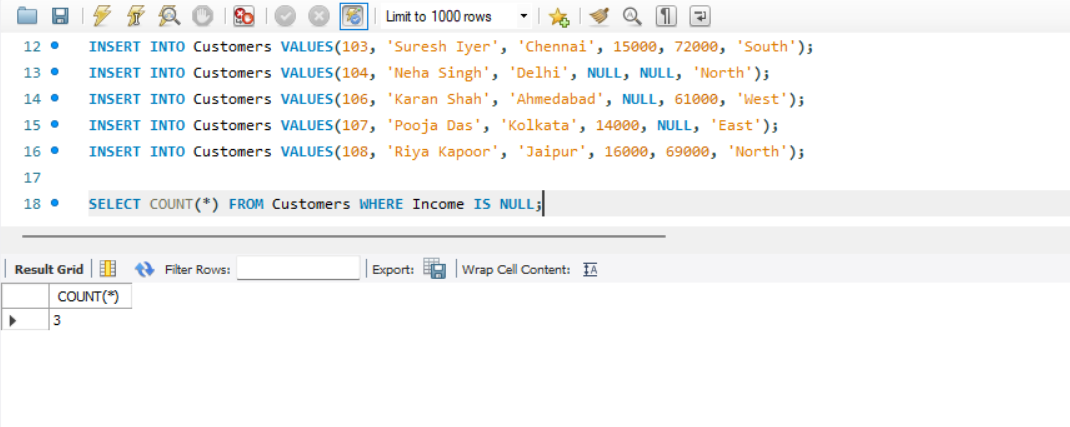

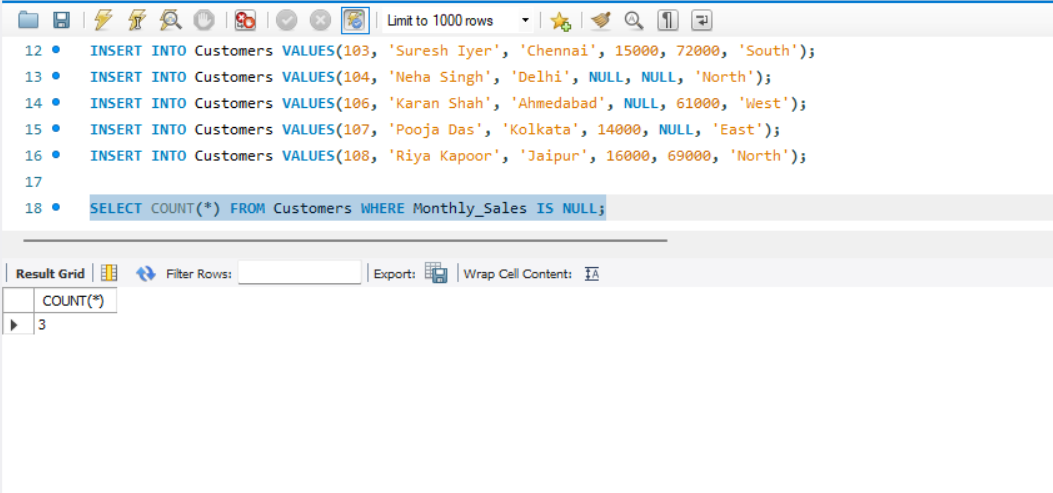

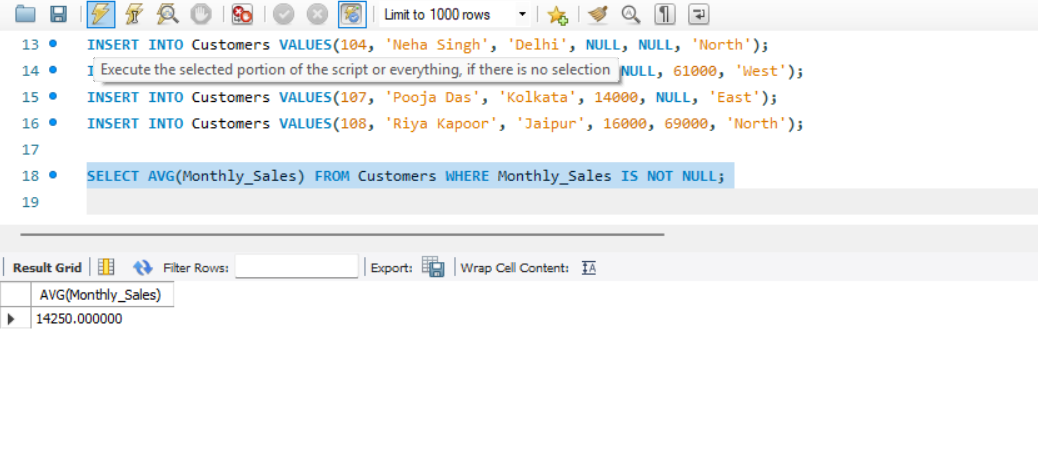




---

Q9  Imputation

Handle missing values in Monthly_Sales using:

Forward Fill

Tasks:

Apply forward fill

Show before vs after values

Explain why forward fill is suitable here

A) Forward fill is a missing value imputation technique where each missing entry in a dataset is replaced with the last observed non‑missing value.

Imagine data flowing down a column like water: whenever there’s a gap, the last known value “fills” it until a new value appears.

**How It Works**

 - Start at the top of the column.

- Each time you encounter a missing value, look upward to the most recent valid entry.

- Copy that value downward into the missing slot.

- Continue until the next non‑missing value appears, then repeat.

**Sequential Nature of Data **

Monthly sales are time‑ordered. If one month’s entry is missing, it often means “no update yet,” so carrying forward the last known figure is logical.

**Preserves Continuity**

Unlike mean or median imputation, forward fill doesn’t break the natural flow of the time series. It keeps the dataset consistent for trend analysis.

**Business Context**

In sales reporting, missing values usually occur because data wasn’t recorded, not because sales dropped to zero. Forward fill assumes stability until new information arrives.

**Simple and Effective **

It’s computationally light and easy to implement, making it a practical choice for ETL pipelines and dashboards.

**Limitations**

- If sales fluctuate heavily month to month, forward fill may mask real changes.

- It assumes stability, which works best in short gaps but may distort longer missing stretches.


---

Q10. Flagging Missing Data

Create a flag column for missing Income.

Tasks:

Create Income_Missing_Flag (0 = present, 1 = missing)

Show updated dataset

Count how many customers have missing income

A) 🔹 What is a Missing Data Flag?
A flag column is an indicator variable added to the dataset that marks whether a value is missing or present.

0 → Value is present (not missing)

1 → Value is missing

This doesn’t replace the missing value; it simply records its status.

🔹 Why Create an Income_Missing_Flag?

**Transparency **

Analysts can clearly see which records had missing income, even after imputation or cleaning.

**Auditability**

If you later fill in missing values (e.g., with median or forward fill), you still retain a record of which entries were originally incomplete.

**Predictive Power**

Sometimes, the fact that income is missing is itself meaningful. For example, customers who don’t disclose income may behave differently (e.g., higher credit risk). The flag allows models to capture this hidden signal.

🔹 Counting Missing Income
Once the flag is created, you can easily count how many customers have missing income by summing the flag column:

Example: If Income_Missing_Flag has values [0,1,0,1,1], the sum = 3, meaning 3 customers have missing income.



---

